In [2]:
import sys

sys.path.append(r"C:\Users\com125\Desktop\Parth_Intern\SRC")

from load_data import convert_tsf_to_dataframe
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import sys

sys.path.append(r"C:\Users\com125\Desktop\Parth_Intern\SRC")

from metrics import get_metrics
from backtesting import train_test_split

In [4]:
from load_data import convert_tsf_to_dataframe
import pandas as pd

df, frequency, horizon, missing, equal_length = (
    convert_tsf_to_dataframe(
        r"C:\Users\com125\Desktop\Parth_Intern\DATA\us_births_dataset.tsf"
    )
)

values = df["series_value"][0]

start_date = df["start_timestamp"][0]

births_df = pd.DataFrame({"date": pd.date_range(start=start_date, periods=len(values), freq="D"), "births": values})
births_df.head()

,date,births
0,1969-01-01,8486.0
1,1969-01-02,9002.0
2,1969-01-03,9542.0
3,1969-01-04,8960.0
4,1969-01-05,8390.0


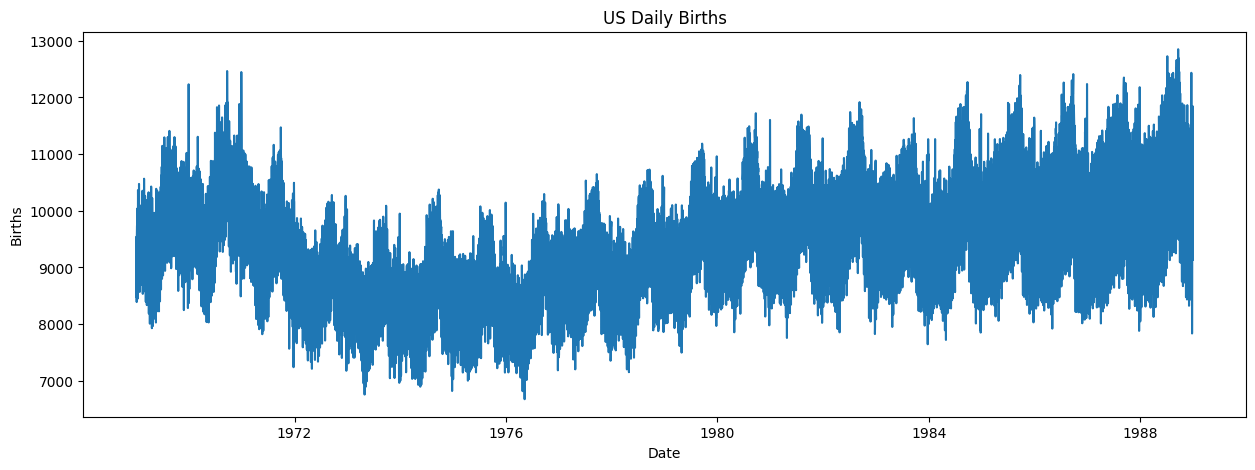

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(births_df["date"], births_df["births"])
plt.title("US Daily Births")
plt.xlabel("Date")
plt.ylabel("Births")

plt.show()

In [6]:
q1 = births_df["births"].quantile(0.25)
q3 = births_df["births"].quantile(0.75)

iqr = q3 - q1

lb = q1 - (1.5 * iqr)
ub = q3 + (1.5 * iqr)

outlier_days = births_df[
    (births_df["births"] < lb)
    | (births_df["births"] > ub)
]
print(f"Number of outlier observations: {len(outlier_days)}")

Number of outlier observations: 0


month
1      9288.975806
2      9491.300885
3      9464.741935
4      9267.958333
5      9331.000000
6      9597.618333
7     10032.733871
8     10177.038710
9     10343.286667
10     9766.729032
11     9492.121667
12     9523.187097
Name: births, dtype: float64


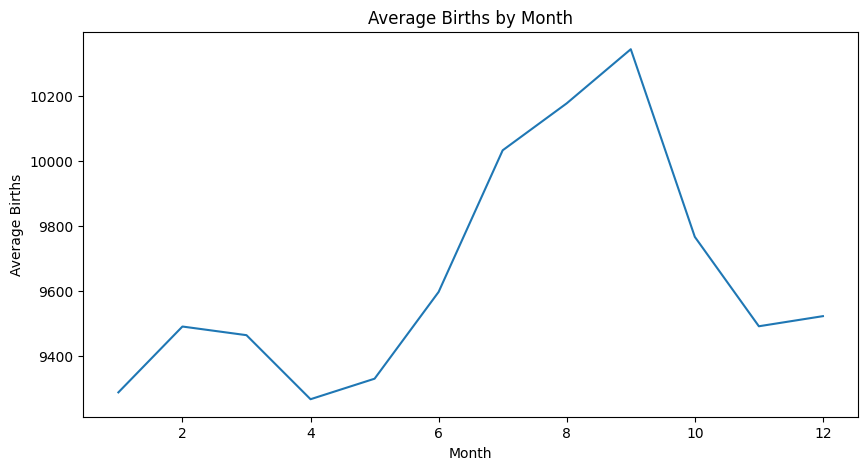

In [7]:
births_df["month"] = births_df["date"].dt.month

mon = births_df.groupby("month")["births"].mean()
print(mon)
mon.plot(figsize=(10, 5))

plt.title("Average Births by Month")
plt.xlabel("Month")
plt.ylabel("Average Births")

plt.show()

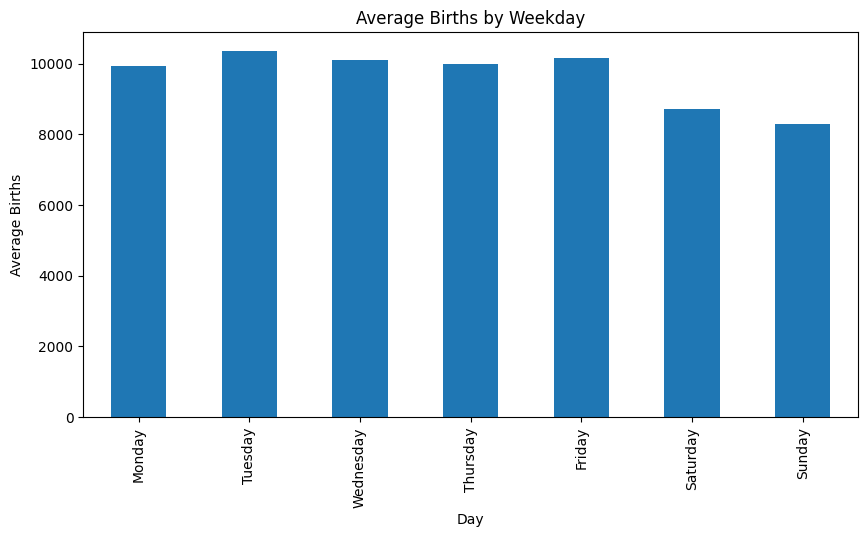

In [8]:
births_df["day"] = births_df["date"].dt.day_name()

days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
wk = births_df.groupby("day")["births"].mean().reindex(days)

wk.plot(kind="bar", figsize=(10, 5))
plt.title("Average Births by Weekday")
plt.xlabel("Day")
plt.ylabel("Average Births")

plt.show()

In [9]:
n = len(births_df)

split = int(n * 0.8)

train = births_df.iloc[:split].copy()
test = births_df.iloc[split:].copy()

print("Train:", len(train))
print("Test:", len(test))

Train: 5844
Test: 1461


In [10]:
# base line 
pred = []

hist = list(train["births"])

for y in test["births"]:

    f = hist[-1]

    pred.append(f)

    hist.append(y)

In [11]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import numpy as np

mae = mean_absolute_error(
    test["births"],
    pred
)

rmse = np.sqrt(
    mean_squared_error(
        test["births"],
        pred
    )
)

mape = (
    np.mean(
        np.abs(
            (test["births"] - pred)
            / test["births"]
        )
    ) * 100
)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 896.495550992471
RMSE: 1270.5940576798564
MAPE: 8.94132831269034


In [12]:
pred_seasonal = []

hist = list(train["births"])

for y in test["births"]:

    f = hist[-7]

    pred_seasonal.append(f)

    hist.append(y)

In [13]:
mae_s = mean_absolute_error(
    test["births"],
    pred_seasonal
)

rmse_s = np.sqrt(
    mean_squared_error(
        test["births"],
        pred_seasonal
    )
)

mape_s = (
    np.mean(
        np.abs(
            (test["births"] - pred_seasonal)
            / test["births"]
        )
    ) * 100
)

print("MAE :", mae_s)
print("RMSE:", rmse_s)
print("MAPE:", mape_s)

MAE : 308.92470910335385
RMSE: 532.6132499843238
MAPE: 2.9998293581547038


In [14]:
def walk_forward_naive(data, start):

    actual = []
    pred = []

    hist = list(data[:start])

    for y in data[start:]:

        f = hist[-1]

        pred.append(f)
        actual.append(y)

        hist.append(y)

    return actual, pred

In [15]:
series = births_df["births"].values

split = int(len(series) * 0.8)

actual, pred = walk_forward_naive(
    series,
    split
)

In [16]:
def walk_forward_seasonal(data, start, lag=7):

    actual = []
    pred = []

    hist = list(data[:start])

    for y in data[start:]:

        f = hist[-lag]

        pred.append(f)
        actual.append(y)

        hist.append(y)

    return actual, pred

actual_s, pred_s = walk_forward_seasonal(
    series,
    split,
    lag=7
)

In [17]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(actual, pred)

rmse = np.sqrt(
    mean_squared_error(actual, pred)
)

mape = (
    np.mean(
        np.abs(
            (np.array(actual) - np.array(pred))
            / np.array(actual)
        )
    ) * 100
)

print(mae, rmse, mape)


mae_s = mean_absolute_error(actual_s, pred_s)

rmse_s = np.sqrt(
    mean_squared_error(actual_s, pred_s)
)

mape_s = (
    np.mean(
        np.abs(
            (np.array(actual_s) - np.array(pred_s))
            / np.array(actual_s)
        )
    ) * 100
)

print(mae_s, rmse_s, mape_s)

896.495550992471 1270.5940576798564 8.94132831269034
308.92470910335385 532.6132499843238 2.9998293581547038


In [18]:
results = {
    "Model": ["Naive", "Seasonal Naive"],
    "MAE": [896.50, 308.92],
    "RMSE": [1270.59, 532.61],
    "MAPE": [8.94, 3.00]
}

import pandas as pd

res_df = pd.DataFrame(results)

print(res_df)

            Model     MAE     RMSE  MAPE
0           Naive  896.50  1270.59  8.94
1  Seasonal Naive  308.92   532.61  3.00


In [19]:
import sys

sys.path.append(
    r"C:\Users\com125\Desktop\Parth_Intern\SRC"
)

from models.prophet_model import (
    train_model,
    forecast
)

from metrics import (
    get_metrics,
    mase
)

c:\Users\com125\Desktop\Parth_Intern\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [20]:
import pandas as pd
from load_data import convert_tsf_to_dataframe

df, frequency, horizon, missing, equal_length = (
    convert_tsf_to_dataframe(
        r"C:\Users\com125\Desktop\Parth_Intern\DATA\us_births_dataset.tsf"
    )
)

vals = df["series_value"][0]

start = df["start_timestamp"][0]

births_df = pd.DataFrame({
    "date": pd.date_range(
        start=start,
        periods=len(vals),
        freq="D"
    ),
    "births": vals
})

births_df.head()

,date,births
0,1969-01-01,8486.0
1,1969-01-02,9002.0
2,1969-01-03,9542.0
3,1969-01-04,8960.0
4,1969-01-05,8390.0


In [21]:
births_df.shape

(7305, 2)

In [22]:
prophet_df = births_df[ ["date", "births"]].copy()

prophet_df.columns = [ "ds","y"]

In [23]:
split = int(len(prophet_df) * 0.8)

train_p = prophet_df.iloc[:split]

test_p = prophet_df.iloc[split:]

In [24]:
model = train_model(train_p)

14:31:10 - cmdstanpy - INFO - Chain [1] start processing
14:31:12 - cmdstanpy - INFO - Chain [1] done processing


In [25]:
pred_df = forecast(model,len(test_p))

In [26]:
pred_p = pred_df["yhat"].tail(
    len(test_p)
).values

actual_p = test_p["y"].values

In [27]:
mase_p = mase(
    actual_p,
    pred_p,
    train_p["y"].values
)

print("MASE:", mase_p)

MASE: 0.9258327533934954


In [28]:
mae_p, rmse_p, mape_p = get_metrics(
    actual_p,
    pred_p
)

print("MAE :", mae_p)
print("RMSE:", rmse_p)
print("MAPE:", mape_p)

MAE : 591.3824450363946
RMSE: 718.894417201485
MAPE: 5.47258587142342


In [29]:
mase_p = mase(
    actual_p,
    pred_p,
    train_p["y"].values
)

print("MASE:", mase_p)

MASE: 0.9258327533934954


In [30]:
xgb_df = births_df.copy()

xgb_df["lag1"] = xgb_df["births"].shift(1)
xgb_df["lag7"] = xgb_df["births"].shift(7)
xgb_df["lag14"] = xgb_df["births"].shift(14)
xgb_df["lag30"] = xgb_df["births"].shift(30)

xgb_df["dow"] = xgb_df["date"].dt.dayofweek
xgb_df["month"] = xgb_df["date"].dt.month

xgb_df = xgb_df.dropna()

xgb_df.head()

,date,births,lag1,lag7,lag14,lag30,dow,month
30,1969-01-31,9692.0,9674.0,9798.0,9974.0,8486.0,4,1
31,1969-02-01,9130.0,9692.0,9022.0,9312.0,9002.0,5,2
32,1969-02-02,8814.0,9130.0,8568.0,8622.0,9542.0,6,2
33,1969-02-03,9988.0,8814.0,9910.0,9808.0,8960.0,0,2
34,1969-02-04,9996.0,9988.0,10032.0,10474.0,8390.0,1,2


In [31]:
split = int(len(xgb_df) * 0.8)

train_x = xgb_df.iloc[:split]
test_x = xgb_df.iloc[split:]

In [32]:
cols = [
    "lag1",
    "lag7",
    "lag14",
    "lag30",
    "dow",
    "month"
]

X_train = train_x[cols]
y_train = train_x["births"]

X_test = test_x[cols]
y_test = test_x["births"]

In [33]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

model_xgb.fit(
    X_train,
    y_train
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [34]:
pred_xgb = model_xgb.predict(X_test)

In [35]:
mae_x, rmse_x, mape_x = get_metrics(
    y_test,
    pred_xgb
)

print("MAE :", mae_x)
print("RMSE:", rmse_x)
print("MAPE:", mape_x)

MAE : 282.22333917257305
RMSE: 418.533235177202
MAPE: 2.687884187117374


In [36]:
mase_x = mase(
    y_test,
    pred_xgb,
    y_train
)

print("MASE:", mase_x)

MASE: 0.44135853967242


In [37]:
import matplotlib.pyplot as plt
err = pred_xgb - y_test

over = err[err > 0]
under = err[err < 0]

over_cost = abs(over).sum()

under_cost = abs(under).sum() * 2

print("Over Forecast Cost :", over_cost)
print("Under Forecast Cost:", under_cost)

Over Forecast Cost : 117245.5458984375
Under Forecast Cost: 586778.8251953125


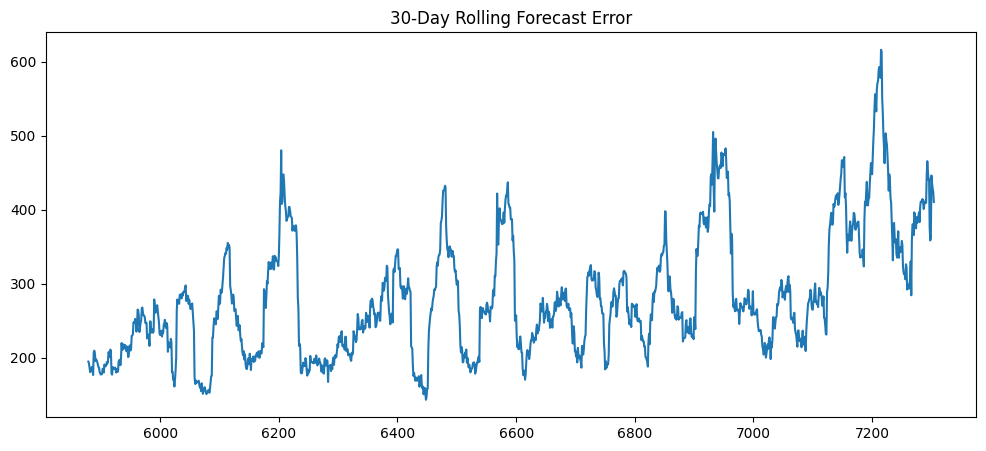

In [38]:
err_series = abs(y_test - pred_xgb)

err_series = pd.Series(err_series)

err_series.rolling(
    30
).mean().plot(
    figsize=(12,5)
)

plt.title("30-Day Rolling Forecast Error")
plt.show()

In [39]:
results = pd.DataFrame({
    "Model": [
        "Naive",
        "Seasonal Naive",
        "Prophet",
        "XGBoost"
    ],
    "MAE": [
        896.50,
        308.92,
        591.38,
        282.22
    ],
    "RMSE": [
        1270.59,
        532.61,
        718.89,
        418.53
    ],
    "MAPE": [
        8.94,
        3.00,
        5.47,
        2.69
    ]
})

results

,Model,MAE,RMSE,MAPE
0,Naive,896.50,1270.59,8.94
1,Seasonal Naive,308.92,532.61,3.00
2,Prophet,591.38,718.89,5.47
3,XGBoost,282.22,418.53,2.69


In [40]:
results.to_csv(
    "model_comparison.csv",
    index=False
)

In [41]:
err = pred_xgb - y_test

over = err[err > 0]
under = err[err < 0]

over_cost = abs(over).sum()

under_cost = abs(under).sum() * 2

total_cost = over_cost + under_cost

print("Over Forecast Cost :", over_cost)
print("Under Forecast Cost:", under_cost)
print("Total Cost :", total_cost)

Over Forecast Cost : 117245.5458984375
Under Forecast Cost: 586778.8251953125
Total Cost : 704024.37109375


In [42]:
import sys

sys.path.append(
    r"C:\Users\com125\Desktop\Parth_Intern\SRC"
)

from drift_monitor import rolling_error

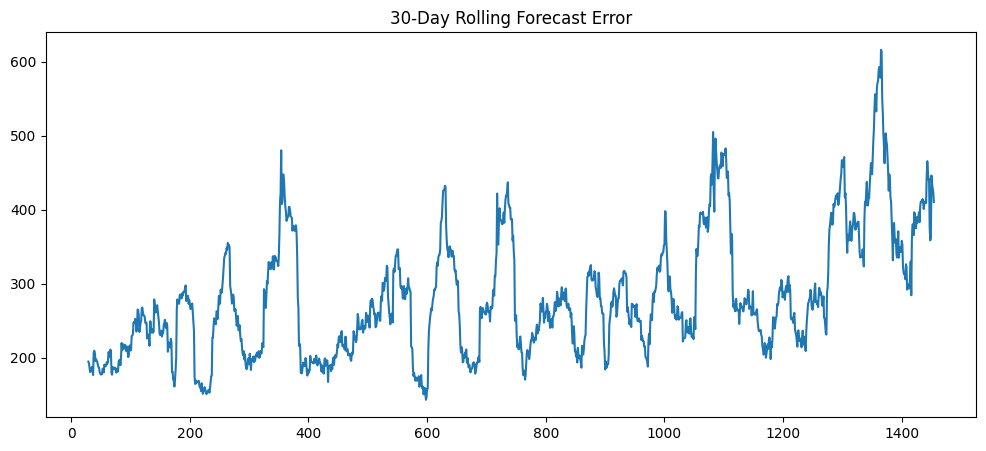

In [43]:
drift = rolling_error(
    y_test.values,
    pred_xgb
)

drift.plot(
    figsize=(12,5)
)

plt.title(
    "30-Day Rolling Forecast Error"
)

plt.show()

In [44]:
first_half = err_series[:len(err_series)//2].mean()
second_half = err_series[len(err_series)//2:].mean()

print("First Half Error :", first_half)
print("Second Half Error:", second_half)

First Half Error : 251.44005894300207
Second Half Error: 312.9643346765539


In [45]:
import joblib

joblib.dump(
    model_xgb,
    r"C:\Users\com125\Desktop\Parth_Intern\SRC\models\xgb_model.pkl"
)

print("saved")

saved


In [46]:
import os

print(
    os.path.exists(
        r"C:\Users\com125\Desktop\Parth_Intern\SRC\models\xgb_model.pkl"
    )
)

True


In [47]:
births_df.to_csv(
    r"C:\Users\com125\Desktop\Parth_Intern\DATA\births_clean.csv",
    index=False
)

print("saved")

saved


In [48]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [49]:
get_metrics(y_test, pred_rf)

(276.90166323024056,
 np.float64(415.7743476676838),
 np.float64(2.6537426841979355))

In [50]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [51]:
mae_lr, rmse_lr, mape_lr = get_metrics(y_test, pred_lr)

print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("MAPE:", mape_lr)

MAE : 325.335219700991
RMSE: 466.94946679223403
MAPE: 3.168885337080217


In [52]:
mase_lr = mase(y_test, pred_lr, y_train)

print("MASE:", mase_lr)

MASE: 0.5087795994910034


In [53]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [54]:
mae_rf, rmse_rf, mape_rf = get_metrics(y_test, pred_rf)

print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("MAPE:", mape_rf)

MAE : 276.90166323024056
RMSE: 415.7743476676838
MAPE: 2.6537426841979355


In [55]:
mase_rf = mase(y_test, pred_rf, y_train)

print("MASE:", mase_rf)

MASE: 0.4330361694198255


In [56]:
from statsmodels.tsa.arima.model import ARIMA
from metrics import get_metrics, mase

split = int(len(births_df) * 0.8)
tr = births_df["births"][:split]
te = births_df["births"][split:]

ar = ARIMA(tr, order=(7,1,1))

fit = ar.fit()

pred_ar = fit.forecast(steps=len(te))

mae_ar, rmse_ar, mape_ar = get_metrics(te, pred_ar)

print("MAE :", mae_ar)
print("RMSE:", rmse_ar)
print("MAPE:", mape_ar)

mase_ar = mase(te, pred_ar, tr)

print("MASE:", mase_ar)

c:\Users\com125\Desktop\Parth_Intern\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


MAE : 1175.9536792913389
RMSE: 1286.56547977925
MAPE: 11.240349292325162
MASE: 1.8410022852377856


c:\Users\com125\Desktop\Parth_Intern\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [57]:
from sklearn.ensemble import ExtraTreesRegressor

et = ExtraTreesRegressor(n_estimators=200, random_state=42)

et.fit(X_train, y_train)

pred_et = et.predict(X_test)

In [58]:
mae_et, rmse_et, mape_et = get_metrics(y_test, pred_et)

print("MAE :", mae_et)
print("RMSE:", rmse_et)
print("MAPE:", mape_et)

mase_et = mase(y_test, pred_et, y_train)

print("MASE:", mase_et)

MAE : 277.249147766323
RMSE: 401.1870154040776
MAPE: 2.641204770906123
MASE: 0.43357958750797415


In [59]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=42)

gbr.fit(X_train, y_train)

pred_gbr = gbr.predict(X_test)

In [60]:
mae_gbr, rmse_gbr, mape_gbr = get_metrics(y_test, pred_gbr)

print("MAE :", mae_gbr)
print("RMSE:", rmse_gbr)
print("MAPE:", mape_gbr)

mase_gbr = mase(y_test, pred_gbr, y_train)

print("MASE:", mase_gbr)

MAE : 289.76468472274956
RMSE: 445.08688203825176
MAPE: 2.7664127113495445
MASE: 0.4531521683246405


In [61]:
a=X_train.shape
b=X_test.shape
print(a,b)

(5820, 6) (1455, 6)


In [62]:
c = X_train.to_numpy()[0] + X_test.to_numpy()[0]
print(c)

[1.8151e+04 1.9903e+04 1.8549e+04 1.6945e+04 4.0000e+00 2.0000e+00]


In [63]:
births_df.shape

(7305, 2)

In [64]:
#autogluon

In [71]:
from autogluon.tabular import TabularPredictor

tr = X_train.copy()
tr["births"] = y_train

ag = TabularPredictor(label="births", eval_metric="mae")

ag.fit(tr, presets="medium_quality")

pred_ag = ag.predict(X_test)

mae_ag, rmse_ag, mape_ag = get_metrics(y_test, pred_ag)

print("MAE :", mae_ag)
print("RMSE:", rmse_ag)
print("MAPE:", mape_ag)

mase_ag = mase(y_test, pred_ag, y_train)

print("MASE:", mase_ag)

No path specified. Models will be saved in: "AutogluonModels\ag-20260603_091907"
Verbosity: 2 (Standard Logging)
	Failed to import torch or check CUDA availability!Please ensure you have the correct version of PyTorch installed by running `pip install -U torch`
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.3
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.19045
CPU Count:          8
Pytorch Version:    Can't import torch
CUDA Version:       Can't get cuda version from torch
Memory Avail:       6.25 GB / 15.83 GB (39.5%)
Disk Space Avail:   87.09 GB / 222.92 GB (39.1%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ...
AutoGluon will save models to "c:\Users\com125\Desktop\Parth_Intern\NOTEBOOK\AutogluonModels\ag-20260603_091907"
Train Data Rows:    5820
Train Data Columns: 6
Label Column:       births
AutoGluon infers your p

MAE : 274.5639708843428
RMSE: 402.6328806648535
MAPE: 2.6153022780303474
MASE: 0.429380339668063


In [72]:
ag.leaderboard()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-179.657670,mean_absolute_error,0.114238,3.130596,0.000459,0.028591,2,True,4
1,XGBoost,-180.406302,mean_absolute_error,0.004962,0.631155,0.004962,0.631155,1,True,3
2,ExtraTreesMSE,-186.373888,mean_absolute_error,0.048681,0.708754,0.048681,0.708754,1,True,2
3,RandomForestMSE,-190.661179,mean_absolute_error,0.060136,1.762096,0.060136,1.762096,1,True,1


In [73]:
ag.fit_summary()

*** Summary of fit() ***
Estimated performance of each model:
                 model   score_val          eval_metric  pred_time_val  fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0  WeightedEnsemble_L2 -179.657670  mean_absolute_error       0.114238  3.130596                0.000459           0.028591            2       True          4
1              XGBoost -180.406302  mean_absolute_error       0.004962  0.631155                0.004962           0.631155            1       True          3
2        ExtraTreesMSE -186.373888  mean_absolute_error       0.048681  0.708754                0.048681           0.708754            1       True          2
3      RandomForestMSE -190.661179  mean_absolute_error       0.060136  1.762096                0.060136           1.762096            1       True          1
Number of models trained: 4
Types of models trained:
{'XTModel', 'RFModel', 'WeightedEnsembleModel', 'XGBoostModel'}
Bagging used: False 
Multi

c:\Users\com125\Desktop\Parth_Intern\venv\Lib\site-packages\autogluon\core\utils\plots.py:169: UserWarning: AutoGluon summary plots cannot be created because bokeh is not installed. To see plots, please do: "pip install bokeh==2.0.1"
  warnings.warn('AutoGluon summary plots cannot be created because bokeh is not installed. To see plots, please do: "pip install bokeh==2.0.1"')


{'model_types': {'RandomForestMSE': 'RFModel',
  'ExtraTreesMSE': 'XTModel',
  'XGBoost': 'XGBoostModel',
  'WeightedEnsemble_L2': 'WeightedEnsembleModel'},
 'model_performance': {'RandomForestMSE': -190.6611789559171,
  'ExtraTreesMSE': -186.37388752416237,
  'XGBoost': -180.40630201621565,
  'WeightedEnsemble_L2': -179.65767037827536},
 'model_best': 'WeightedEnsemble_L2',
 'model_paths': {'RandomForestMSE': ['RandomForestMSE'],
  'ExtraTreesMSE': ['ExtraTreesMSE'],
  'XGBoost': ['XGBoost'],
  'WeightedEnsemble_L2': ['WeightedEnsemble_L2']},
 'model_fit_times': {'RandomForestMSE': 1.7620964050292969,
  'ExtraTreesMSE': 0.7087535858154297,
  'XGBoost': 0.631155252456665,
  'WeightedEnsemble_L2': 0.028590679168701172},
 'model_pred_times': {'RandomForestMSE': 0.060135841369628906,
  'ExtraTreesMSE': 0.04868125915527344,
  'XGBoost': 0.00496220588684082,
  'WeightedEnsemble_L2': 0.00045871734619140625},
 'num_bag_folds': 0,
 'max_stack_level': 2,
 'model_hyperparams': {'RandomForestMSE'

In [74]:
pred_ag = ag.predict(X_test)

mae_ag, rmse_ag, mape_ag = get_metrics(y_test, pred_ag)

print("MAE :", mae_ag)
print("RMSE:", rmse_ag)
print("MAPE:", mape_ag)

mase_ag = mase(y_test, pred_ag, y_train)

print("MASE:", mase_ag)

MAE : 274.5639708843428
RMSE: 402.6328806648535
MAPE: 2.6153022780303474
MASE: 0.429380339668063
